# Getting Started

This guide walks you through setting up and running your first BLonD simulation using the EX_01_Acceleration example.

## Overview


A BLonD simulation consists of several key components:

1. Physical components (Ring, RF stations, Drift sections)
2. Beam definition
3. Energy/magnetic cycle
4. Beam preparation
5. Observations
6. Simulation execution

## Setting Up the Simulation


### Creating the Ring

The ring defines the circumference of your accelerator and
holds all elements that are executed for simulating the beam behaviour:

In [1]:
from matplotlib import pyplot as plt
from copy import deepcopy
import blond
from blond.testing import pytest_active

pytest_is_active = pytest_active()

Using environment variable BLOND_BACKEND_MODE = python
Changing backend to `Numpy64Bit`


In [2]:
if not pytest_is_active:
    blond.backend.set_specials(
        "numba"
    )  # select a faster backend, if available.

Set special to `numba`


### Setting Up the Energy Cycle


The magnetic cycle defines how the beam energy evolves during the simulation. BLonD provides several types of cycles.

#### Constant Energy

For simulations with constant beam energy (no acceleration):

In [3]:
from blond import Ring

ring = Ring(26658.883)  # circumference in meters

In [4]:
from blond import ConstantMagneticCycle, proton

energy_cycle = ConstantMagneticCycle(
    reference_particle=proton,
    value=450e9,  # energy value
    in_unit="total energy",  # can be 'momentum', 'total energy', 'kinetic energy', or 'bending field'
)

This is the simplest and most efficient option when the beam energy doesn't change.


#### Energy Ramp (Per Turn)

For simulations with acceleration, where energy changes turn-by-turn:

In [5]:
from blond.cycles.magnetic_cycle import MagneticCyclePerTurn
from blond import proton
import numpy as np

N_TURNS = int(1e3)

energy_cycle = MagneticCyclePerTurn(
    reference_particle=proton,
    value_init=450e9,  # initial energy
    values_after_turn=np.linspace(
        450e9, 460e9, N_TURNS
    ),  # energy after each turn
    in_unit="total energy",
)

The cycle assumes each RF station provides an equal fraction of the energy kick per turn.


#### Advanced Cycle Options

**Per-RF-Station Control (MagneticCyclePerTurnAllRfStations)**

For full control over each RF station's contribution at each turn:


In [6]:
from blond.cycles.magnetic_cycle import MagneticCyclePerTurnAllRFStations

# REQUIRED: 2D array with shape (n_rf_stations, n_turns)
# Each row represents one RF station, each column represents one turn
# Example for 4 RF stations and 1000 turns:
n_rf_stations = 4
N_TURNS = 1000

energy_per_rf_station = np.zeros((n_rf_stations, N_TURNS))
# Write the desired values in `energy_per_rf_station`
energy_cycle = MagneticCyclePerTurnAllRFStations(
    reference_particle=proton,
    value_init=450e9,
    values_after_rf_station_per_turn=energy_per_rf_station,  # 2D array: (rf_stations, turns)
    in_unit="total energy",
)

**Time-Based Cycle (MagneticCycleByTime)**

For cycles defined by continuous time interpolation:

In [7]:
from blond.cycles.magnetic_cycle import MagneticCycleByTime
from scipy.interpolate import interp1d

time_points = np.array([0, 1.0, 2.0, 3.0])  # time in seconds
energy_values = np.array([450e9, 500e9, 600e9, 700e9])

energy_cycle = MagneticCycleByTime(
    reference_particle=proton,
    base_time=time_points,
    base_values=energy_values,
    in_unit="total energy",
    interpolator=interp1d,  # interpolation function
)

All cycle types support the ``in_unit`` parameter with options: ``'momentum'``, ``'total energy'``, ``'kinetic energy'``, or ``'bending field'``.


### Defining RF Stations

RF stations provide acceleration and longitudinal focusing. A single harmonic
RF station is defined by its harmonic number, voltage, and phase:

In [8]:
from blond import SingleHarmonicRFStation

rf_station1 = SingleHarmonicRFStation()
rf_station1.harmonic = 35640  # harmonic number
rf_station1.voltage = 6e6  # voltage in V
rf_station1.phi_rf_design = 0  # RF phase in radians

It is also possible to plan the value of those variables ahead in time. This will also work for drifts.

In [9]:
rf_station1.schedule("voltage", 6e6 * np.ones(N_TURNS))

### Configuring Drift Sections

Drift sections represent regions without RF stations:


In [10]:
from blond import DriftSimple, momentum_compaction_factor

drift1 = DriftSimple(orbit_length=26658.883)
drift1.momentum_compaction_factor = momentum_compaction_factor(
    transition_gamma=55.759505
)

### Setting up the Beam Profile

In [11]:
from blond import StaticProfile

profile1 = StaticProfile(
    cut_left=0,
    cut_right=energy_cycle.get_t_rev_init(ring.circumference)
    / rf_station1.get_main_harmonic(),
    n_bins=256,
)

### Wakefields

Wakefields/impedances will disturb the beam by inducing additional voltages that affect the beam dynamics.

In [12]:
from blond import WakeField, TimeDomainFftSolver, Resonators

wakefield1 = WakeField(
    sources=(Resonators(200e3, 200e6, 10e10),),
    solver=TimeDomainFftSolver(),
    profile=profile1,
)

### Assembling the Simulation

The ``Simulation.from_locals()`` method automatically discovers and connects all components defined in the local scope:


## Populating the Beam

The beam object holds particle information:


In [13]:
from blond import Beam, proton

beam1 = Beam(
    intensity=1e9,  # number of real particles
    particle_type=proton,  # particle type
)

In [14]:
from blond import Simulation

sim = Simulation.from_locals(locals())
sim.print_one_turn_execution_order()  # optional: print execution order

------------------------------------------------------------------------------
Execution order
---------------
element.name                             type                 section_index filtered_dict
Unnamed-StaticProfile-001                StaticProfile        0             {'each_turn_i': 1, 'active': True, 'observables': {}, 'hist_y_to_density_factor': None, 'hist_step': 9.746406684678538e-12, 'cut_left': 8.077935669463161e-28, 'cut_right': 2.495080111277706e-09, 'bin_edges': "<class 'numpy.ndarray'>(min=8.077935669463161e-28, max=2.495080111277706e-09, shape=(257,))", 'gradient_hist_y': "<class 'numpy.ndarray'>(min=0.0, max=0.0, shape=(256,))", 'n_bins': 256}
 ↓ Unnamed-StaticProfile-001             StaticProfile        0             {'each_turn_i': 1, 'active': True, 'observables': {}, 'hist_y_to_density_factor': None, 'hist_step': 9.746406684678538e-12, 'cut_left': 8.077935669463161e-28, 'cut_right': 2.495080111277706e-09, 'bin_edges': "<class 'numpy.ndarray'>(min=8.077935669463

The ``locals()`` function returns a dictionary of all variables in the current scope. ``Simulation.from_locals()`` inspects this dictionary and automatically detects all BLonD components (ring, RF stations, drifts, beam, energy cycle) without requiring you to pass each one explicitly.


Before running the simulation, the beam phase space must be populated with macroparticles. BLonD offers several beam preparation methods:


### BiGaussian Distribution

The most commonly used method creates a simple Gaussian distribution in both time and energy:


In [15]:
from blond import BiGaussian

sim.prepare_beam(
    beam=beam1,
    preparation_routine=BiGaussian(
        sigma_dt=0.4e-9 / 4,  # time spread (standard deviation) in seconds
        sigma_dE=1e9 / 4,  # energy spread (standard deviation) in eV
        seed=1,  # random seed for reproducibility
        n_macroparticles=1e6,  # number of macroparticles
    ),
)

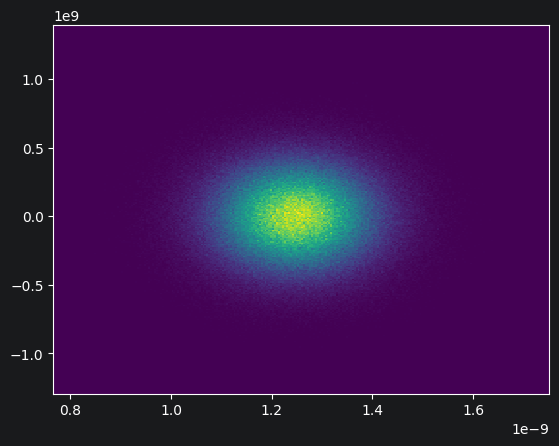

In [16]:
beam1.plot_hist2d()

This creates 1000 macroparticles with a Gaussian distribution. It's simple, fast, and suitable for most applications.


### Semi-Empiric Matcher (Experimental)

A physics-based matching approach that uses the Hamiltonian to generate matched distributions:

For this, you need to know how your potential well looks like and how much of it to populate.

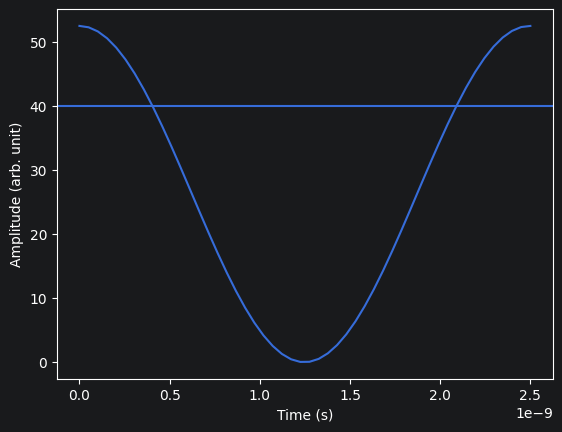

In [17]:
sim.plot_potential_well_empiric(
    dt=np.linspace(0, 2.5e-9),
    particle_type=proton,
)
hamilton_max = 40
_ = plt.axhline(hamilton_max)

/home/slauber/PycharmProjects/deleteme/blonder/blond/experimental/__init__.py:38: ExperimentalFeaturesWarning: 
Importing experimental features. These are under development and are
liable to change or be removed without warning.

  warnings.warn(_msg, ExperimentalFeaturesWarning, stacklevel=1)


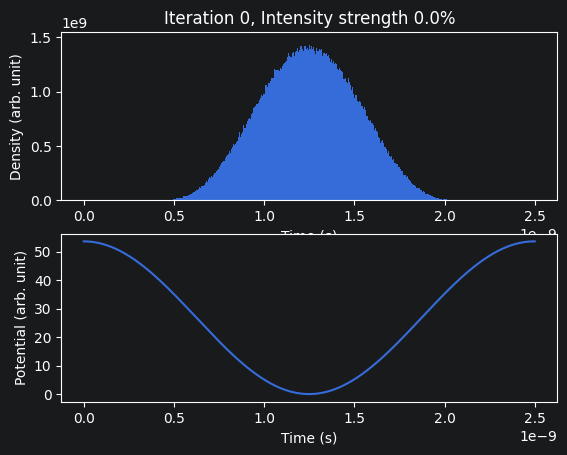

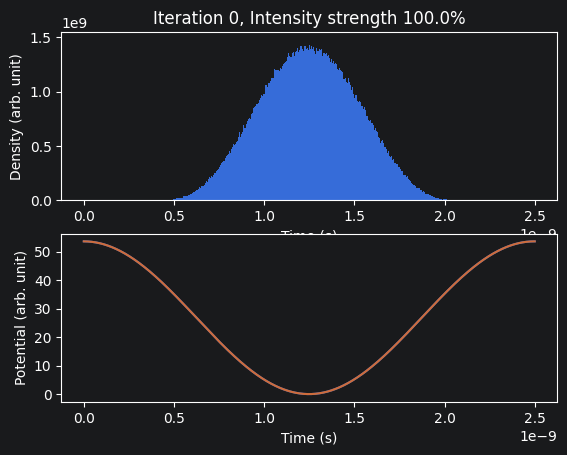

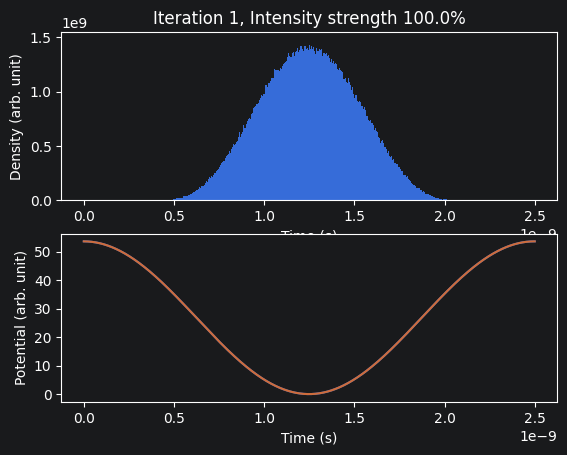

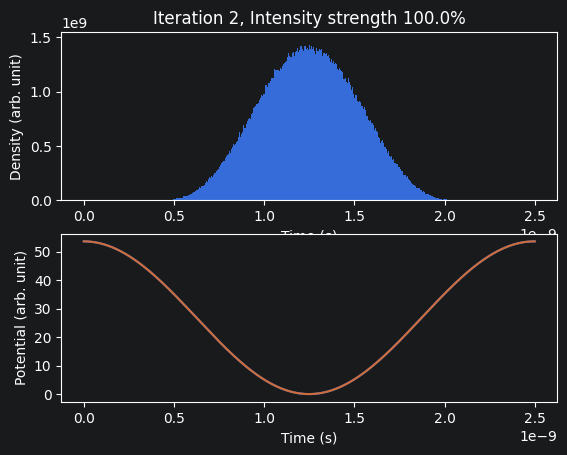

Iteration: 2     | Intensity 100.0% | Error: 0.000000


In [18]:
from blond.experimental.beam_preparation.semi_empiric_matcher import (
    SemiEmpiricMatcher,
)

sim.prepare_beam(
    beam=beam1,
    preparation_routine=SemiEmpiricMatcher(
        time_limit=(0, 2.5e-9),
        n_macroparticles=1e6,
        seed=0,
        hamilton_to_density_kwargs=dict(
            density_modifier=2.0,  # Controls density profile sharpness
            hamilton_max=hamilton_max,  # Hamiltonian cutoff [eV]
        ),
        animate=True,
    ),
)

This method calculates the Hamiltonian and generates particles following matched trajectories, making it ideal for stationary distributions.


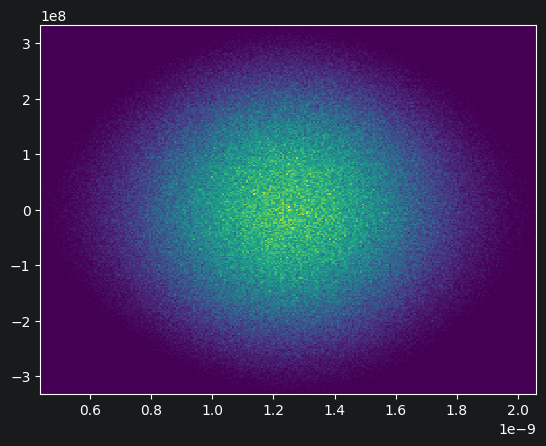

In [19]:
beam1.plot_hist2d()


### XSuite RF Bucket Matcher

For users working with XSuite, BLonD provides an interface to XSuite's RF bucket matching:

In [ ]:
from blond.interfaces.xsuite.beam_preparation.rfbucket_matching import (
    XsuiteRFBucketMatcher,
)
from xpart.longitudinal.rfbucket_matching import QGaussianDistribution

sim.prepare_beam(
    beam=beam1,
    preparation_routine=XsuiteRFBucketMatcher(
        distribution_type=QGaussianDistribution,  # or ThermalDistribution, ParabolicDistribution
        sigma_z=sim.ring.circumference / (8 * np.amin(rf_station1.harmonic)),
        n_macroparticles=1e6,
        seed=42,
    ),
)

*** Maximum RMS bunch length 0.162779325944828m.
... distance to target bunch length: -9.3501e-02
... distance to target bunch length: 5.8222e-02
... distance to target bunch length: 2.9259e-02
... distance to target bunch length: -3.8744e-02
... distance to target bunch length: -3.7152e-03
... distance to target bunch length: -5.6177e-05
... distance to target bunch length: 1.5689e-06
... distance to target bunch length: -7.0366e-10
... distance to target bunch length: 6.6649e-07
--> Bunch length: 0.09350057098545834


In [ ]:
beam1.plot_hist2d()

This requires the ``xpart`` package and allows using XSuite's advanced stationary distributions.

### Other Methods

Additional beam preparation methods are under development in the ``blond.experimental.beam_preparation`` module. Check the source code for the latest available options.


## Setting Up Observations

Observations allow you to record data during the simulation for later analysis. BLonD provides several observation classes for different purposes.


### Available Observations

#### BeamObservationEndOfTurn - Complete Beam Distribution

Records the full longitudinal phase space coordinates (time and energy) of all macroparticles at the end of each specified turn, allowing you to analyze beam evolution and create phase space plots.


In [ ]:
from blond import BeamObservationOncePerTurn

bunch_observation = BeamObservationOncePerTurn(
    each_turn_i=1,  # record every turn
)

Access recorded data via:

- ``bunch_observation.dts``: Time coordinates [s] for all particles (shape: n_turns × n_macroparticles)
- ``bunch_observation.dEs``: Energy deviations [eV] for all particles (shape: n_turns × n_macroparticles)
- ``bunch_observation.flags``: Particle status flags (e.g., lost particles)
- ``bunch_observation.reference_time``: Reference time per turn [s]
- ``bunch_observation.reference_total_energy``: Reference energy per turn [eV]


#### BunchObservationMetaParams - Statistical Parameters

Records mean and standard deviation of time and energy coordinates, plus the statistical emittance:


In [ ]:
from blond.handle_results.observables import BeamStatisticsOncePerTurn

stats_observation = BeamStatisticsOncePerTurn(
    each_turn_i=1,  # record every turn
)

Access recorded data via:

- ``stats_observation.bunch_position``: Mean time coordinate [s]
- ``stats_observation.bunch_length``: Time coordinate standard deviation [s]
- ``stats_observation.energy_spread``: Energy deviation standard deviation [eV]
- ``stats_observation.reference_time``:  Reference total energy [eV]


#### RfStationPhaseObservation - RF Station Parameters

Tracks the evolution of RF station parameters (phase, frequency, voltage):

In [ ]:
from blond import RFStationPhaseObservation

phase_observation = RFStationPhaseObservation(
    each_turn_i=1,  # record every turn
    rf_station=rf_station1,  # which RF station to observe
)

Access recorded data via:

- ``phase_observation.phases``: RF phase [rad] (shape: n_turns × n_harmonics)
- ``phase_observation.omegas``: Angular frequency [rad/s] (shape: n_turns × n_harmonics)
- ``phase_observation.voltages``: RF voltage [V] (shape: n_turns × n_harmonics)

#### DriftObservation - Drift Parameters

In [ ]:
from blond import DriftObservation

drift_observation = DriftObservation(
    each_turn_i=1,
    drift=drift1,
)

#### StaticProfileObservation - Beam Profile (Fixed Bins)

Observes a beam profile with fixed bin positions and widths:

In [ ]:
from blond.handle_results.observables import StaticProfileObservation

profile_observation = StaticProfileObservation(
    each_turn_i=1,
    profile=profile1,
)

Access recorded data via:

- ``profile_obs.hist_y``: Histogram amplitudes (shape: n_observations × n_bins)

#### StaticMultiProfileObservation - Many Profiles

If you want to have acess to sucessive profiles via a common observation.

In [ ]:
from blond.handle_results.observables import StaticMultiProfileObservation

multi_profile_observation = StaticMultiProfileObservation(
    each_turn_i=1,
    profiles=(profile1,),
)


Access recorded data via:

- ``profile_obs.hist_y``: Histogram amplitudes (shape: n_turns × n_bins)
- ``profile_obs.hist_x``: Bin center positions [s] (shape: n_turns × n_bins)


#### WakeFieldObservation - Wake Field Effects

Observes the induced voltage from wake fields. Note that this observation is independent of the wakefield solver or impedance model used - it simply records the calculated induced voltage regardless of whether you're using resonators, impedance tables, or other wake field implementations:


In [ ]:
from blond.handle_results.observables import WakeFieldObservation

wake_observation = WakeFieldObservation(
    each_turn_i=1,
    wakefield=wakefield1,  # observes the resulting induced voltage
)

Access recorded data via:

- ``wake_obs.induced_voltage``: Induced voltage [V] from wake fields (independent of solver type)


Common Parameters

All observations support these common parameters:

- ``each_turn_i``: Controls recording frequency. Set to 1 to record every turn, 10 to record every 10th turn, etc.
- ``folder``: Optional path prefix for saving/loading data to disk.
 Some observation support also:
- ``obs_per_turn``: For observations that support it, allows multiple recordings per turn at different RF sections. Maximum value is the number of RF stations.


### Contributing New Observations

If you need to observe quantities not provided by the existing observation classes, you can implement your own by:

1. Inheriting from ``ObservablesEndOfTurnBase`` (in ``blond.handle_results.observables``)
2. Implementing the required methods: ``on_run_simulation()`` and ``update()``
3. Using ``DenseArrayRecorder`` to efficiently store time-series data

We encourage you to **contribute your new observations to the main BLonD project** via a pull request on GitHub. This helps the entire community benefit from your work and ensures your observations are maintained and tested.

For examples, see the existing implementations in ``blond/handle_results/observables.py``.


## Running the Simulation

### Basic Execution

Run the simulation with the defined observations:

In [ ]:
sim.run_simulation(
    beams=(deepcopy(beam1),),
    n_turns=15,
    observe=(
        bunch_observation,
        stats_observation,
        phase_observation,
        drift_observation,
        profile_observation,
        multi_profile_observation,
        wake_observation,
    ),
)

In [ ]:
sim.save_results(observe=(stats_observation,))

### Custom Callbacks

You can define custom actions to execute during the simulation:

In [ ]:
from matplotlib import pyplot as plt
from blond import copy_to_cpu


def custom_action(simulation: Simulation, beam: Beam):
    if simulation.turn_i.value % 10 != 0:
        return

    plt.scatter(
        copy_to_cpu(beam.read_partial_dt()),
        copy_to_cpu(beam.read_partial_dE()),
    )
    plt.draw()
    plt.pause(0.1)
    plt.clf()


plt.ion()
sim.run_simulation(
    beams=(beam1,),
    n_turns=10,
    observe=(phase_observation, bunch_observation),
    callbacks=custom_action,  # custom action called each turn
)

### Loading Cached Results

BLonD can cache simulation results. Use a try-except block to load cached results or run a new simulation:

In [ ]:
sim.load_results(
    beams=(beam1,),
    n_turns=N_TURNS,
    observe=(stats_observation,),
)

## Analyzing Results

After the simulation completes, you can access the recorded observations.

### Plotting Phase Evolution

In [ ]:
from matplotlib import pyplot as plt

plt.plot(profile_observation.hist_x.T, profile_observation.hist_y.T)
plt.xlabel("Time [s]")
plt.ylabel("Intensity [arb. unit]")
plt.show()

## Next Steps

- Explore other examples in the ``blond/examples/`` directory
- Learn about intensity effects and collective effects
- Understand different RF station types and RF programs
- Experiment with different beam preparation methods